<a href="https://colab.research.google.com/github/Nawaljabeen/M.A.R.S-Metric-Augumented-Retrieval-System-/blob/main/notebooks/MARS_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Set Up**

In [ ]:
!pip uninstall -q google-generativeai -y
!pip install -q -U google-genai


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 783.6/783.6 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.6/240.6 kB 17.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.47.0, but you have google-auth 2.49.2 which is incompatible.


**Environment SETUP**

In [1]:
#mounting drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
REPO_URL = "https://github.com/Nawaljabeen/M.A.R.S-Metric-Augumented-Retrieval-System-.git"
REPO_NAME = "M.A.R.S-Metric-Augumented-Retrieval-System-"

repo_path = f"/content/{REPO_NAME}"

%cd /content

if not os.path.exists(repo_path):
    !git clone {REPO_URL}
    print(" Repo cloned!")
else:

    %cd {repo_path}
    !git pull
    %cd /content
    print(" Repo updated to latest version!")

/content
/content/M.A.R.S-Metric-Augumented-Retrieval-System-
Already up to date.
/content
🔄 Repo updated to latest version!


In [4]:
#BLENDER INSTALLATION
import os

#Download the Linux version of Blender 4.0
!wget -nc https://download.blender.org/release/Blender4.0/blender-4.0.2-linux-x64.tar.xz

#Extract the file
!tar xf blender-4.0.2-linux-x64.tar.xz

#Add Blender to the system path
blender_path = "/content/blender-4.0.2-linux-x64"
os.environ["PATH"] += f":{blender_path}"

#Check if  working
!blender -v

--2026-05-02 19:49:45--  https://download.blender.org/release/Blender4.0/blender-4.0.2-linux-x64.tar.xz
Resolving download.blender.org (download.blender.org)... 172.66.172.236, 104.20.41.146, 2606:4700:10::6814:2992, ...
Connecting to download.blender.org (download.blender.org)|172.66.172.236|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 277588768 (265M) [application/octet-stream]
Saving to: ‘blender-4.0.2-linux-x64.tar.xz’

blender-4.0.2-linux 100%[===================>] 264.73M   250MB/s    in 1.1s    

2026-05-02 19:49:46 (250 MB/s) - ‘blender-4.0.2-linux-x64.tar.xz’ saved [277588768/277588768]

Blender 4.0.2
	build date: 2023-12-05
	build time: 08:48:50
	build commit date: 2023-12-05
	build commit time: 07:41
	build hash: 9be62e85b727
	build platform: Linux
	build type: release
	build c flags:  -Wall -Werror=implicit-function-declaration -Wstrict-prototypes -Werror=return-type -Werror=vla -Wmissing-prototypes -Wno-char-subscripts -Wno-unknown-pragmas -Wpo

In [6]:
# 1. Enable pip inside Blender
!blender -b --python-expr "import sys, subprocess; subprocess.run([sys.executable, '-m', 'ensurepip'])"

# 2. Install the full batch of Infinigen's core dependencies
!blender -b --python-expr "import sys, subprocess; subprocess.run([sys.executable, '-m', 'pip', 'install', 'gin-config', 'trimesh', 'scipy', 'networkx', 'tqdm'])"

Blender 4.0.2 (hash 9be62e85b727 built 2023-12-05 08:48:50)
Looking in links: /tmp/tmp0ksf2cv5

Blender quit
Blender 4.0.2 (hash 9be62e85b727 built 2023-12-05 08:48:50)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 28.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 17.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 82.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 10.1 MB/s eta 0:00:00

Blender quit


In [5]:
#APIKEYCODEBLOCK

#RUN THIS ONCE PER SESSION!!

from google import genai
from google.colab import userdata


client = genai.Client(api_key=userdata.get('GEMINI_API_KEY'))


try:
    response = client.models.generate_content(
        model='gemini-3-flash-preview',
        contents="System Check: Are you ready to generate Blender Python code?"
    )
    print(f"Assistant: {response.text}")
except Exception as e:

    print(f"❌ Connection Failed. Technical Details: {e}")

Assistant: **System Check: Online.**

Yes, I am fully prepared to generate, debug, and optimize **Blender Python (`bpy`)** code.

Whether you need a simple automation script or a complex add-on, I can assist with:

1.  **Object Manipulation:** Creating, transforming, and parenting meshes, lights, and cameras.
2.  **Procedural Modeling:** Generating geometry via bmesh or math-based algorithms.
3.  **Materials & Shaders:** Automating node setups in Cycles and Eevee.
4.  **Animation:** Setting keyframes, handling drivers, and managing the timeline.
5.  **Geometry Nodes:** Controlling and automating GN modifiers through the API.
6.  **UI Customization:** Creating custom panels, menus, and operators for the Sidebar (N-panel).
7.  **Batch Processing:** Importing/exporting files or rendering sequences via script.

---

### Quick Example: Procedural Staircase
To test the integration, here is a quick script that generates a basic staircase. You can paste this into Blender’s **Text Editor** and 

**DEVELOPMENT ZONE**

📤 Please upload a furniture image to start the M.A.R.S. pipeline:


Saving brimnesbed.jpg to brimnesbed (2).jpg

🚀 [PIPELINE TRIGGERED] Processing: brimnesbed (2).jpg


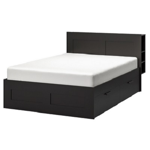

   👁️ Running Constrained Gemini Vision extraction...

    [DEBUG] RAW GEMINI JSON OUTPUT:
   ----------------------------------------
{
  "search_params": {
    "category": "Beds",
    "size_intent": "Medium",
    "keywords": "bed, platform, dark wood, headboard"
  },
  "component_recipe": [
    {
      "type": "surface",
      "shape": "square",
      "is_cushion": false,
      "z_position_ratio": 0.2,
      "scale_w": 1.0,
      "scale_d": 1.0,
      "thickness_ratio": 0.4
    },
    {
      "type": "surface",
      "shape": "square",
      "is_cushion": true,
      "z_position_ratio": 0.5,
      "scale_w": 0.9,
      "scale_d": 0.85,
      "thickness_ratio": 0.2
    },
    {
      "type": "backrest",
      "is_cushion": false,
      "z_position_ratio": 0.7,
      "thickness_m": 0.05,
      "scale_w": 1.0,
      "y_position": "back"
    }
  ]
}
   ----------------------------------------

    PARSED -> Category: 'Beds' | Size: 'Medium' | Keywords: 'bed, platform, dark wood, headboar

In [20]:
import os
import json
import re
import io
from PIL import Image
from google.colab import files

# --- 1. LOAD DATABASE & EXTRACT CATEGORIES ---
JSON_PATH = "/content/M.A.R.S-Metric-Augumented-Retrieval-System-/ikea_rag_pristine.json"

if not os.path.exists(JSON_PATH):
    print(" ERROR: JSON is missing! Please upload it.")
    ikea_data = []
    unique_categories = []
else:
    with open(JSON_PATH, 'r') as f:
        ikea_data = json.load(f)
    unique_categories = list(set([item['category'] for item in ikea_data]))

# --- 2. THE UNIVERSAL SMART SCORING RETRIEVAL ---
def retrieve_ikea_metrics(target_category, search_keywords, size_intent):
    if not ikea_data:
        return {"width_m": 0.45, "depth_m": 0.50, "height_m": 0.85}

    category_items = [item for item in ikea_data if item['category'].lower() == target_category.lower() and item['width_m'] > 0.1]

    if not category_items:
        print(f"   ⚠️ [DEBUG] Could not find any items in category '{target_category}'!")
        return {"width_m": 0.45, "depth_m": 0.50, "height_m": 0.85}

    highest_score = -1
    tied_items = []
    keyword_list = [kw.strip().lower() for kw in search_keywords.split(",")]

    for item in category_items:
        score = 0
        content = item['rag_content'].lower()
        name = item['name'].lower()

        for i, kw in enumerate(keyword_list):
            if kw in content or kw in name:
                if i == 0:
                    score += 5
                elif i == 1:
                    score += 3
                else:
                    score += 1

        if " / " in item['name']:
            score -= 1

        if "leg" in content and "table" in content and not "table," in content:
            score -= 10

        if score > highest_score:
            highest_score = score
            tied_items = [item]
        elif score == highest_score:
            tied_items.append(item)

    print(f"   📊 [DEBUG] Found {len(tied_items)} items tied with a high score of {highest_score}.")
    for i, t_item in enumerate(tied_items[:5]):
        print(f"      - Option {i+1}: {t_item['name']} (W:{t_item['width_m']} D:{t_item['depth_m']} H:{t_item['height_m']})")
    if len(tied_items) > 5:
        print(f"      - ... and {len(tied_items) - 5} more.")

    # --- THE UNIVERSAL TIE-BREAKER ---
    tied_items.sort(key=lambda x: x['width_m'] * x['depth_m'])

    if size_intent == "Small":
        best_item = tied_items[0]
    elif size_intent == "Large":
        best_item = tied_items[-1]
    else:
        best_item = tied_items[len(tied_items) // 2]

    print(f"\n   🏆 [WINNER CHOSEN]")
    print(f"      Name: {best_item['name']}")
    print(f"      Score: {highest_score}")
    print(f"      Intent Applied: {size_intent}")
    print(f"      JSON Description: {best_item['rag_content']}")

    return {"width_m": best_item['width_m'], "depth_m": best_item['depth_m'], "height_m": best_item['height_m']}


# --- 3. THE PIPELINE ---

def process_uploaded_image(filename, image_bytes):
    print(f"\n🚀 [PIPELINE TRIGGERED] Processing: {filename}")

    try:
        img = Image.open(io.BytesIO(image_bytes))
        display(img.resize((150, 150)))
    except Exception as e:
        print(f"❌ Failed to read image: {e}")
        return

    print("   👁️ Running Constrained Gemini Vision extraction...")
    categories_string = ", ".join(unique_categories)

    # --- THE NEW STRICT JSON SCHEMA PROMPT ---
    vision_prompt = f"""
    You are an expert structural CAD engineer. Analyze the attached image of furniture.
You MUST choose a category from this exact list: [{categories_string}]

Output a strict JSON object with exactly TWO top-level keys: "search_params" and "component_recipe".

1. "search_params": MUST contain:
   - "category": Exact match from the list above.
   - "size_intent": "Small", "Medium", or "Large".
   - "keywords": 3 to 4 comma-separated words (e.g., "table, coffee, wood").

2. "component_recipe": An array of objects detailing the geometry. You are STRICTLY RESTRICTED to these types:
   - `surface`: Tops, seats, and horizontal shelves. MUST include `shape` ("square", "circular", "oval").
   - `support`: Vertical legs or pillars holding up a surface. MUST include `count` (integer) and `shape` ("box" or "cylinder").
   - `backrest`: Vertical back supports for chairs, sofas, or beds.
   - `armrest`: Horizontal side supports for chairs/sofas.
   - `base`: Floor mounts (tripods, flat discs).
   - `storage_box`: Solid volumes like cabinets, drawers. (CRITICAL: If building a bed, u cannot have storage).

   UNIVERSAL MODIFIERS for components (Use only when necessary):
   - `is_cushion`: Boolean (True if soft/upholstered, False if hard wood/metal).
   - `z_position_ratio`: Float (0.0 to 1.0) indicating vertical placement (0.0 is floor, 1.0 is top).
   - `scale_w` / `scale_d`: Float (0.1 to 1.0) indicating width/depth relative to the bounding box.
   - `thickness_ratio`: Float. Thickness as a percentage of total height (Used for surfaces/storage).
   - `thickness_m`: Float. Absolute physical thickness in meters (Used for supports, backrests, and armrests. Default is ~0.05).
   - `pitch_angle`: Integer (degrees). Add ONLY for splayed legs or tilted backs.
   - `x_position`: String ("left", "right", "center"). Add ONLY for asymmetrical left/right items.
   - `y_position`: String ("front", "back", "center"). Add ONLY for items pushed to the front/back edges.
    """

    # Force Gemini to output pure JSON
    response = client.models.generate_content(
        model='gemini-2.5-flash', # Updated to latest standard model
        contents=[img, vision_prompt],
        config={'response_mime_type': 'application/json'}
    )

    print("\n    [DEBUG] RAW GEMINI JSON OUTPUT:")
    print("   "+"-"*40)
    print(response.text)
    print("   "+"-"*40+"\n")

    # --- JSON PARSING AND VALIDATION ---
    try:
        ai_data = json.loads(response.text)
        search_params = ai_data.get("search_params", {})
        recipe = ai_data.get("component_recipe", [])

        category = search_params.get("category", "Tables & desks")
        size_intent = search_params.get("size_intent", "Medium")
        keywords = search_params.get("keywords", "")
    except json.JSONDecodeError:
        print(" ERROR: Gemini did not return valid JSON. Aborting.")
        return

    print(f"    PARSED -> Category: '{category}' | Size: '{size_intent}' | Keywords: '{keywords}'")

    print("    Retrieving best-scored metrics from IKEA database...")
    # Call your existing RAG function!
    metrics = retrieve_ikea_metrics(category, keywords, size_intent)

    # --- THE DATA COMBINER (This is what your partner needs!) ---
    final_payload = {
        "overall_bounding_box": {
            "width_m": metrics['width_m'],
            "depth_m": metrics['depth_m'],
            "height_m": metrics['height_m']
        },
        "component_recipe": recipe
    }

    # Save to a JSON file so the Blender orchestrator can read it
    output_filepath = f"/content/mars_payload_{filename.split('.')[0]}.json"
    with open(output_filepath, 'w') as f:
        json.dump(final_payload, f, indent=4)

    print(f"\n✅ Pipeline complete! Master payload saved to: {output_filepath}")
    return output_filepath
# --- 4. UPLOAD TRIGGER ---
if os.path.exists(JSON_PATH):
    print("📤 Please upload a furniture image to start the M.A.R.S. pipeline:")
    uploaded = files.upload()
    for filename, data in uploaded.items():
        process_uploaded_image(filename, data)

In [21]:
# THE RUNNER
!blender -b -P /content/M.A.R.S-Metric-Augumented-Retrieval-System-/orchestrator.py

Blender 4.0.2 (hash 9be62e85b727 built 2023-12-05 08:48:50)

 [MARS_LIB] Initializing Universal Assembly...
    Spawning Surface (Z: 0.2)
    Spawning Surface (Z: 0.5)
    Spawning Backrest
[MARS_LIB] Assembly complete!
21:01:07 | INFO: Draco mesh compression is available, use library at /content/blender-4.0.2-linux-x64/4.0/python/lib/python3.10/site-packages/libextern_draco.so
21:01:07 | INFO: Starting glTF 2.0 export
21:01:07 | INFO: Extracting primitive: Cube.004
21:01:07 | INFO: Primitives created: 1
21:01:07 | INFO: Extracting primitive: Cube.002
21:01:07 | INFO: Primitives created: 1
21:01:07 | INFO: Extracting primitive: Cube.003
21:01:07 | INFO: Primitives created: 1
21:01:07 | INFO: Extracting primitive: Cube.001
21:01:07 | INFO: Primitives created: 1
21:01:07 | INFO: Finished glTF 2.0 export in 0.02161121368408203 s


✅ --- SUCCESS: 3D TABLE GENERATED AND SAVED TO /content/drive/MyDrive/MARS/output/mars_brimnesbed2.glb ---

Blender quit


# bpy & infinigen


In [ ]:
import sys
import os


if repo_path not in sys.path:
    sys.path.append(repo_path)

print(f"Checking for library in: {repo_path}")
if os.path.exists(os.path.join(repo_path, "mars_lib.py")):
    print(" mars_lib.py found!")
else:
    print(" mars_lib.py NOT found. Check your folder structure.")

Checking for library in: /content/M.A.R.S-Metric-Augumented-Retrieval-System-
✅ mars_lib.py found!


**VERSION CONTROL**

In [ ]:
#IDENTITY SETUP
import os

user_name = input("Name: ")
user_email = input("Email: ")

!git config --global user.name "{user_name}"
!git config --global user.email "{user_email}"

print(f"✅ Ready! Commits will now be signed as: {user_name}")




Name: Nawaljabeen
Email: jabeennawal@gmail.com
✅ Ready! Commits will now be signed as: Nawaljabeen


In [ ]:
#PUSH FUNCTION
from google.colab import userdata
import os

def push_to_github(commit_message="Daily Update"):
    from google.colab import _message
    _message.blocking_request('save_ipynb', request={'tablet_id': 'default_tablet'}, timeout_sec=5)

    token = userdata.get('MARS_Colab')
    user = "Nawaljabeen"
    repo = "M.A.R.S-Metric-Augumented-Retrieval-System-"

    %cd /content/{repo}
    !git add .
    try:
        !git commit -m "{commit_message}"
        !git push https://{token}@github.com/{user}/{repo}.git main
        print(" Pushed to GitHub!")
    except:
        print("ℹ Nothing to commit.")

    %cd /content
push_to_github("testing fixes for proportion and hallucinatin")

/content/M.A.R.S-Metric-Augumented-Retrieval-System-
[main 179fb06] testing fixes for proportion and hallucinatin
 2 files changed, 17 insertions(+), 16 deletions(-)
Enumerating objects: 9, done.
Counting objects: 100% (9/9), done.
Delta compression using up to 2 threads
Compressing objects: 100% (5/5), done.
Writing objects: 100% (5/5), 1.22 KiB | 1.22 MiB/s, done.
Total 5 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/Nawaljabeen/M.A.R.S-Metric-Augumented-Retrieval-System-.git
   d7f010a..179fb06  main -> main
🚀 Pushed to GitHub!
/content


In [ ]:
%cd /content/M.A.R.S-Metric-Augumented-Retrieval-System-

# 1. Pull the changes from GitHub
# We use --rebase to keep the history clean
!git pull https://{userdata.get('MARS_Colab')}@github.com/Nawaljabeen/M.A.R.S-Metric-Augumented-Retrieval-System-.git main --rebase

n

/content/M.A.R.S-Metric-Augumented-Retrieval-System-
From https://github.com/Nawaljabeen/M.A.R.S-Metric-Augumented-Retrieval-System-
 * branch            main       -> FETCH_HEAD
Successfully rebased and updated refs/heads/main.
